# Clustering Comparison (Continuous): Ours vs KDSC vs TDBM (AV2 val)

The binary comparison (`clustering_comparison.ipynb`) is unreliable when the three methods call very different fractions of agents 'aggressive': the intersection of the three small `aggressive` sets is tiny, so `kappa` / Jaccard say more about prevalence than about ranking.

This notebook compares the methods **continuously**: each method assigns a real-valued *aggression score* to every row, and we compare the three rankings + the per-method feature statistics. No fixed threshold.

**Aggression scores used here:**

| method | score (higher = more aggressive)                                  |
|--------|-------------------------------------------------------------------|
| ours   | `dist(x, normal_center)  - dist(x, aggressive_center)` in our 8-feature standardized space |
| kdsc   | `dist(x, normal_center)  - dist(x, aggressive_center)` in KDSC's 4-feature standardized space |
| tdbm   | `(tdbm_score_0 + 1 + 2) - (tdbm_score_3 + 4 + 5)` (aggressive-side raw score minus calm-side) |

What we report:

1. Spearman & Kendall rank correlations between the three scores.
2. Per-method statistics on a common panel of kinematic features (mean, median, std, p90) for the top-K%, with effect sizes (Cohen's d and the KS statistic) vs the rest.
3. Top-K% overlap and containment ratios at matched prevalence.

Outputs go to `artifacts/comparison_continuous/av2/`.

In [1]:
from __future__ import annotations
import sys, json, pickle, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore', message='.*sklearn.*version.*')

DATASET = 'av2'
TOP_K_PERCENTS = [5, 10, 20, 30]  # for matched-prevalence diagnostics

_CWD = Path.cwd()
for cand in (_CWD, _CWD.parent, _CWD.parent.parent):
    if (cand / 'src').is_dir():
        REPO_ROOT = cand
        break
else:
    REPO_ROOT = _CWD
SRC_ROOT = REPO_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

OURS_PARQUET  = REPO_ROOT / 'artifacts' / 'clustering' / f'{DATASET}_val_clustered.parquet'
OURS_PKL      = REPO_ROOT / 'artifacts' / 'clustering' / 'kmeans_K2.pkl'
KDSC_PARQUET  = REPO_ROOT / 'artifacts' / 'kdsc_replication' / DATASET / f'{DATASET}_val_kdsc.parquet'
KDSC_PKL      = REPO_ROOT / 'artifacts' / 'kdsc_replication' / DATASET / 'kdsc_agglomerative_K2.pkl'
TDBM_PARQUET  = REPO_ROOT / 'artifacts' / 'tdbm_replication' / DATASET / f'{DATASET}_val_tdbm.parquet'

OUT_DIR = REPO_ROOT / 'artifacts' / 'comparison_continuous' / DATASET
FIG_DIR = OUT_DIR / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

for p in (OURS_PARQUET, OURS_PKL, KDSC_PARQUET, KDSC_PKL, TDBM_PARQUET):
    if not p.exists():
        raise FileNotFoundError(p)
print('inputs OK; outputs ->', OUT_DIR)

inputs OK; outputs -> /fs/nexus-projects/pc_driving/yaghoubi/tail-risk-motion-prediction/artifacts/comparison_continuous/av2


## 1. Load and inner-join (same row set as binary notebook)

In [2]:
KEY = ['scenario_id', 'center_objects_id']

def _norm_keys(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['scenario_id']       = out['scenario_id'].astype(str)
    out['center_objects_id'] = out['center_objects_id'].astype(str)
    return out

ours = _norm_keys(pd.read_parquet(OURS_PARQUET))
kdsc = _norm_keys(pd.read_parquet(KDSC_PARQUET))
tdbm = _norm_keys(pd.read_parquet(TDBM_PARQUET))

# Use the TDBM table as the kinematic feature carrier (it preserves the original columns).
kin_cols = [c for c in tdbm.columns if not c.startswith(('tdbm_', 'style_label')) and c not in KEY]
joined = (ours[KEY + ['style_label']]
    .merge(kdsc[KEY + ['style_label_kdsc']], on=KEY, how='inner')
    .merge(tdbm[KEY + ['style_label_tdbm', 'tdbm_raw_style_id', 'tdbm_raw_style_label',
                       'tdbm_has_neighbor'] +
                [c for c in tdbm.columns if c.startswith('tdbm_score_')] +
                kin_cols],
           on=KEY, how='inner'))

print('joined rows:', len(joined))
print('per-method aggressive share:')
for col in ['style_label', 'style_label_kdsc', 'style_label_tdbm']:
    print(f'  {col:18s} {(joined[col] == "aggressive").mean():.3f}')

joined rows: 12387
per-method aggressive share:
  style_label        0.183
  style_label_kdsc   0.000
  style_label_tdbm   0.000


## 2. Build the three continuous aggression scores

In [3]:
with open(OURS_PKL, 'rb') as f:
    ours_bundle = pickle.load(f)
with open(KDSC_PKL, 'rb') as f:
    kdsc_bundle = pickle.load(f)

def _signed_score(df: pd.DataFrame, bundle: dict, *, has_kmeans_model: bool) -> np.ndarray:
    feats = bundle['features']
    scaler = bundle['scaler']
    label_map = bundle['label_map']
    agg_cluster = next(k for k, v in label_map.items() if v == 'aggressive')
    norm_cluster = next(k for k, v in label_map.items() if v == 'normal')

    if has_kmeans_model:
        centers = bundle['model'].cluster_centers_
    else:
        centers = np.asarray(bundle['centroids_standardized'])

    X = df[feats].astype(float).to_numpy()
    Xs = scaler.transform(X)
    d_agg  = np.linalg.norm(Xs - centers[agg_cluster],  axis=1)
    d_norm = np.linalg.norm(Xs - centers[norm_cluster], axis=1)
    return d_norm - d_agg  # >0 means closer to aggressive

score_ours = _signed_score(joined, ours_bundle, has_kmeans_model=True)
score_kdsc = _signed_score(joined, kdsc_bundle, has_kmeans_model=False)

# TDBM: aggressive-side raw classes are {0, 1, 2}; calm side is {3, 4, 5}.
score_cols = [f'tdbm_score_{k}' for k in range(6)]
sc = joined[score_cols].to_numpy(dtype=np.float32)
score_tdbm = sc[:, :3].sum(axis=1) - sc[:, 3:].sum(axis=1)

joined = joined.assign(
    score_ours=score_ours,
    score_kdsc=score_kdsc,
    score_tdbm=score_tdbm,
)

scores_df = joined[['score_ours', 'score_kdsc', 'score_tdbm']]
print('score distributions (higher = more aggressive):')
print(scores_df.describe().round(3))

score distributions (higher = more aggressive):
       score_ours  score_kdsc  score_tdbm
count   12387.000   12387.000   12387.000
mean       -2.079     -20.181  -12098.387
std         2.211       0.633   10258.853
min        -4.197     -20.639  -84745.703
25%        -3.761     -20.450  -16417.772
50%        -3.024     -20.351   -9349.539
75%        -1.047     -20.262   -4723.955
max         4.212     -13.174      33.902


## 3. Rank correlation between methods

Spearman is rank-only and ignores both the score scale and the cluster threshold; Kendall is monotonic-pair agreement. These tell us **how consistently the methods order agents**, independent of where each one draws the aggressive/normal line.

In [4]:
from itertools import combinations

score_names = ['score_ours', 'score_kdsc', 'score_tdbm']
rho_rows = []
for a, b in combinations(score_names, 2):
    s = stats.spearmanr(joined[a], joined[b])
    k = stats.kendalltau(joined[a], joined[b])
    rho_rows.append({
        'pair': f'{a[6:]}_vs_{b[6:]}',
        'spearman_rho': float(s.statistic),
        'spearman_pvalue': float(s.pvalue),
        'kendall_tau': float(k.statistic),
        'kendall_pvalue': float(k.pvalue),
    })
rho_df = pd.DataFrame(rho_rows)
rho_df.to_csv(OUT_DIR / 'rank_correlations.csv', index=False)
rho_df.round(3)

,pair,spearman_rho,spearman_pvalue,kendall_tau,kendall_pvalue
0,ours_vs_kdsc,0.255,0.000,0.169,0.000
1,ours_vs_tdbm,0.049,0.000,0.032,0.000
2,kdsc_vs_tdbm,-0.018,0.042,-0.012,0.041


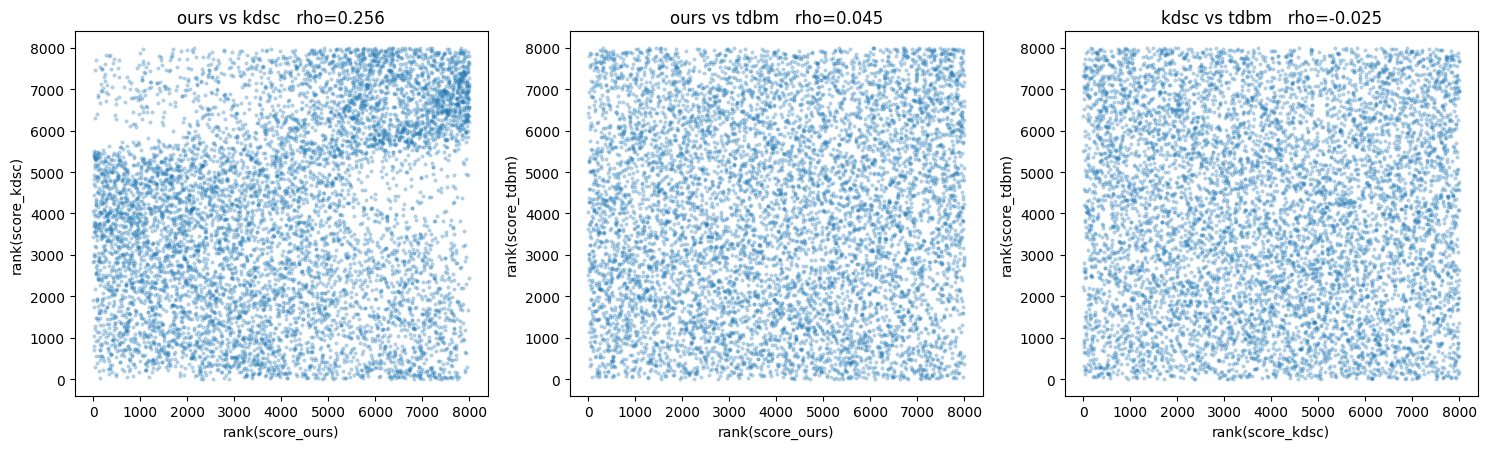

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (a, b) in zip(axes, combinations(score_names, 2)):
    sub = joined[[a, b]].dropna()
    if len(sub) > 8000:
        sub = sub.sample(8000, random_state=42)
    ax.scatter(stats.rankdata(sub[a]), stats.rankdata(sub[b]),
               s=4, alpha=0.25, color='#1f77b4')
    rho = stats.spearmanr(sub[a], sub[b]).statistic
    ax.set_xlabel(f'rank({a})')
    ax.set_ylabel(f'rank({b})')
    ax.set_title(f'{a[6:]} vs {b[6:]}   rho={rho:.3f}')
fig.tight_layout()
fig.savefig(FIG_DIR / 'rank_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

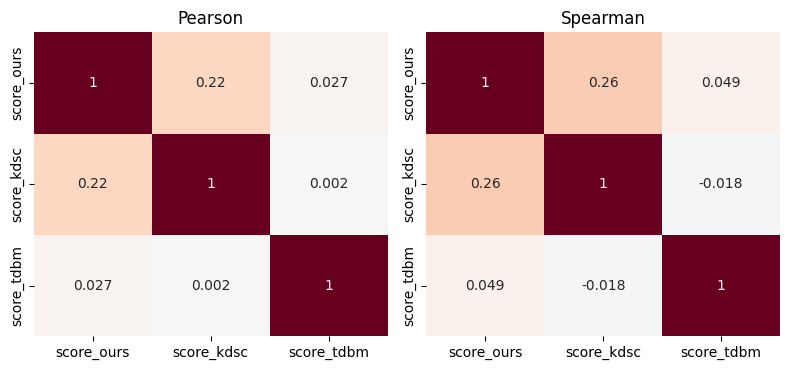

In [6]:
# Pearson correlation on raw scores (sanity reference; sensitive to scale)
pearson = scores_df.corr(method='pearson').round(3)
spearman = scores_df.corr(method='spearman').round(3)
fig, axes = plt.subplots(1, 2, figsize=(8, 3.8))
for ax, mat, title in zip(axes, [pearson, spearman], ['Pearson', 'Spearman']):
    sns.heatmap(mat, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax, cbar=False)
    ax.set_title(title)
fig.tight_layout()
fig.savefig(FIG_DIR / 'score_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Per-method top-K% statistics

Pick the top K% of each method's continuous score, then describe that subset on a fixed panel of kinematic features. Same K for all three methods, so we control for prevalence. Reports:

- per-feature **mean, median, std, p90** for the top-K% subset,
- **Cohen's d** vs the rest (effect size),
- **KS statistic** vs the rest (distributional separation).

A 'good' method here has the top-K% subset with *high* z-score & d on truly aggressive-leaning features (hard braking, lateral G, lateral jerk, heading rate) and not just on raw speed.

In [7]:
STAT_FEATURES = [c for c in [
    'avg_speed', 'max_speed', 'var_speed',
    'max_abs_accel', 'var_acceleration', 'gamma',
    'max_abs_long_accel', 'max_abs_lat_accel',
    'max_abs_jerk', 'max_abs_long_jerk', 'max_abs_lat_jerk',
    'hard_brake_count', 'hard_accel_count',
    'lateral_g_spike_count', 'high_jerk_count',
    'max_abs_heading_rate',
] if c in joined.columns]

def _cohens_d(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    if len(a) < 2 or len(b) < 2:
        return float('nan')
    s = np.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1))
                / (len(a) + len(b) - 2))
    return float((a.mean() - b.mean()) / s) if s > 0 else float('nan')

def topk_stats(score_col: str, k_pct: int) -> pd.DataFrame:
    s = joined[score_col].to_numpy()
    thresh = np.quantile(s, 1 - k_pct / 100)
    top_mask = s >= thresh
    rows = []
    for feat in STAT_FEATURES:
        col = joined[feat].astype(float).to_numpy()
        top, rest = col[top_mask], col[~top_mask]
        if len(top) == 0 or len(rest) == 0:
            continue
        ks = stats.ks_2samp(top, rest)
        rows.append({
            'feature': feat,
            'top_mean':   float(np.mean(top)),
            'top_median': float(np.median(top)),
            'top_std':    float(np.std(top, ddof=1)) if len(top) > 1 else float('nan'),
            'top_p90':    float(np.quantile(top, 0.90)),
            'rest_mean':  float(np.mean(rest)),
            'cohens_d':   _cohens_d(top, rest),
            'ks_stat':    float(ks.statistic),
        })
    return pd.DataFrame(rows)

stats_by_method_topk: dict[tuple[str, int], pd.DataFrame] = {}
for method in ['ours', 'kdsc', 'tdbm']:
    for k in TOP_K_PERCENTS:
        stats_by_method_topk[(method, k)] = topk_stats(f'score_{method}', k)

# wide table at K=10 for quick read
K_FOCUS = 10
wide = pd.concat(
    {method: stats_by_method_topk[(method, K_FOCUS)].set_index('feature')
     for method in ['ours', 'kdsc', 'tdbm']},
    axis=1,
)
wide.to_csv(OUT_DIR / f'topk{K_FOCUS}_feature_stats.csv')
wide.round(3)

ours                                                \
                      top_mean top_median top_std top_p90 rest_mean cohens_d   
feature                                                                        
avg_speed                7.858      7.227   2.390  10.996     9.719   -0.574   
max_speed               10.049      9.704   2.468  13.165    11.204   -0.372   
var_speed                2.399      1.609   2.464   5.745     1.641    0.313   
max_abs_accel            4.998      4.759   1.336   6.667     2.633    1.565   
var_acceleration         1.169      0.979   0.731   2.073     0.436    1.276   
gamma                    6.767      6.332   3.398  11.497     3.050    1.409   
max_abs_long_accel       3.378      2.991   1.674   5.575     2.428    0.603   
max_abs_lat_accel        4.275      4.086   1.072   5.708     1.143    3.514   
max_abs_jerk            29.781     29.300  10.612  44.857    14.698    1.567   
max_abs_long_jerk       18.713     16.764   9.854  33.207    12.934    0.615   
max_abs_lat_jerk        25.180     23.679  10.847  41.173     7.464    2.616   
hard_brake_count         0.596      0.000   1.579   2.000     0.578    0.010   
hard_accel_count         1.504      0.000   2.577   5.000     0.523    0.579   
lateral_g_spike_count    4.243      3.000   4.345  10.000     0.081    2.753   
high_jerk_count         25.762     26.000   8.276  37.000    15.184    1.123   
max_abs_heading_rate     0.650      0.612   0.231   0.897     0.139    3.491   

                                  kdsc                     ...            \
                      ks_stat top_mean top_median top_std  ... rest_mean   
feature                                                    ...             
avg_speed               0.283    8.329      7.810   2.710  ...     9.667   
max_speed               0.173   12.088     11.745   2.709  ...    10.977   
var_speed               0.243    7.276      6.769   3.290  ...     1.099   
max_abs_accel           0.697    5.055      4.448   2.133  ...     2.627   
var_acceleration        0.610    1.321      0.932   1.133  ...     0.419   
gamma                   0.517    5.715      4.755   3.919  ...     3.167   
max_abs_long_accel      0.298    4.756      4.109   2.127  ...     2.275   
max_abs_lat_accel       0.910    1.856      1.236   1.673  ...     1.412   
max_abs_jerk            0.563   24.541     23.144  12.559  ...    15.280   
max_abs_long_jerk       0.325   22.181     20.470  12.043  ...    12.548   
max_abs_lat_jerk        0.722   11.051      7.545   9.976  ...     9.035   
hard_brake_count        0.038    2.677      1.000   3.997  ...     0.347   
hard_accel_count        0.232    2.349      0.000   3.551  ...     0.429   
lateral_g_spike_count   0.896    1.086      0.000   3.043  ...     0.432   
high_jerk_count         0.455   22.118     22.000   9.494  ...    15.589   
max_abs_heading_rate    0.882    0.303      0.175   0.317  ...     0.178   

                                           tdbm                             \
                      cohens_d ks_stat top_mean top_median top_std top_p90   
feature                                                                      
avg_speed               -0.409   0.191    8.786      8.173   2.913  13.013   
max_speed                0.358   0.206   10.478     10.090   2.842  14.241   
var_speed                3.911   0.865    1.934      0.962   2.563   5.038   
max_abs_accel            1.616   0.544    3.102      2.814   1.721   5.305   
var_acceleration         1.633   0.514    0.589      0.367   0.667   1.304   
gamma                    0.923   0.315    3.609      2.614   2.929   7.954   
max_abs_long_accel       1.752   0.608    2.698      2.323   1.661   4.811   
max_abs_lat_accel        0.345   0.109    1.597      1.074   1.391   3.701   
max_abs_jerk             0.902   0.328   17.022     14.150  10.673  33.401   
max_abs_long_jerk        1.058   0.375   14.198     11.144   9.775  28.311   
max_abs_lat_jerk         0.235   0.094    9.51

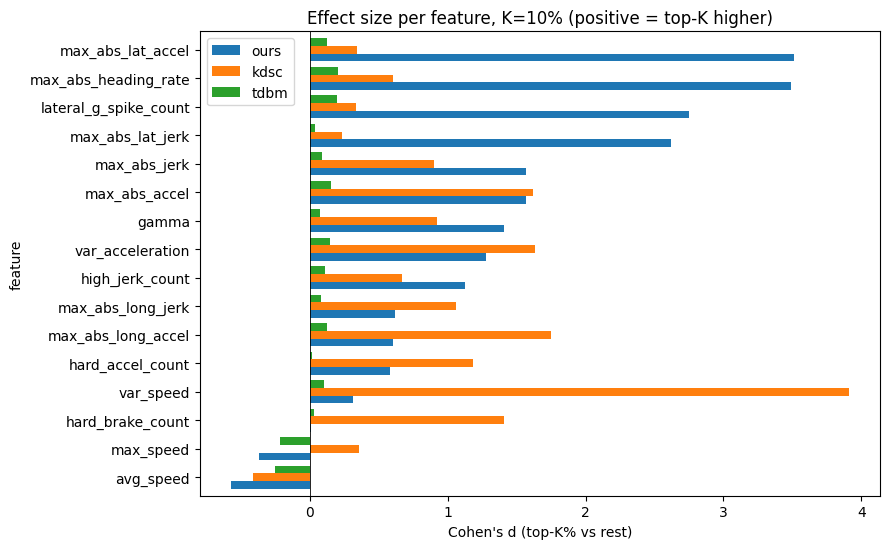

,ours,kdsc,tdbm
feature,,,
avg_speed,-0.574,-0.409,-0.253
max_speed,-0.372,0.358,-0.218
hard_brake_count,0.010,1.407,0.026
var_speed,0.313,3.911,0.099
hard_accel_count,0.579,1.185,0.014
max_abs_long_accel,0.603,1.752,0.121
max_abs_long_jerk,0.615,1.058,0.080
high_jerk_count,1.123,0.670,0.113
var_acceleration,1.276,1.633,0.144


In [8]:
# Effect-size comparison: Cohen's d per feature, per method, at K=10%.
d_df = pd.DataFrame({
    method: stats_by_method_topk[(method, K_FOCUS)].set_index('feature')['cohens_d']
    for method in ['ours', 'kdsc', 'tdbm']
})
d_df = d_df.sort_values('ours', ascending=True)
ax = d_df.plot.barh(figsize=(9, max(4, 0.35 * len(d_df))), width=0.8, edgecolor='none')
ax.axvline(0, color='black', linewidth=0.6)
ax.set_xlabel("Cohen's d (top-K% vs rest)")
ax.set_title(f'Effect size per feature, K={K_FOCUS}% (positive = top-K higher)')
plt.tight_layout()
plt.savefig(FIG_DIR / f'cohens_d_topk{K_FOCUS}.png', dpi=120, bbox_inches='tight')
plt.show()
d_df.round(3)

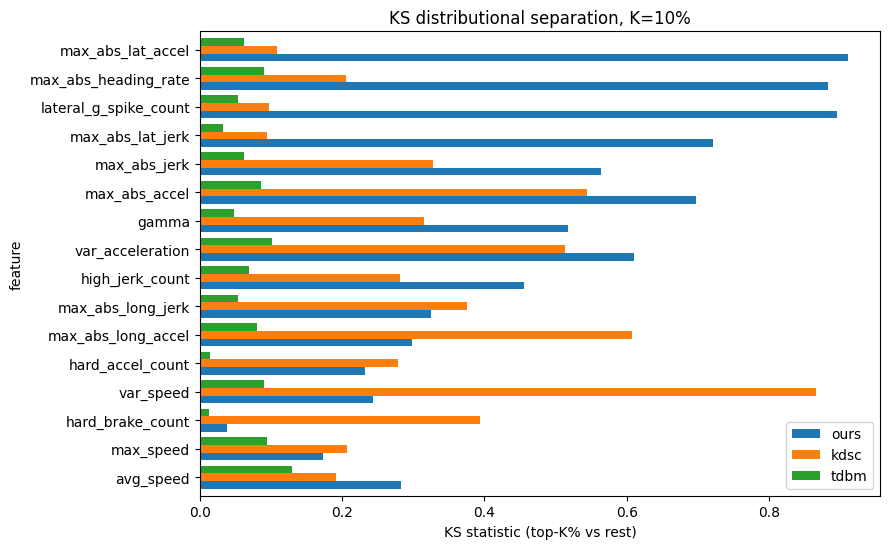

,ours,kdsc,tdbm
feature,,,
avg_speed,0.283,0.191,0.130
max_speed,0.173,0.206,0.095
hard_brake_count,0.038,0.394,0.013
var_speed,0.243,0.865,0.091
hard_accel_count,0.232,0.278,0.014
max_abs_long_accel,0.298,0.608,0.080
max_abs_long_jerk,0.325,0.375,0.053
high_jerk_count,0.455,0.282,0.068
var_acceleration,0.610,0.514,0.101


In [9]:
# Same picture in KS-stat terms (distributional separation, scale-free).
ks_df = pd.DataFrame({
    method: stats_by_method_topk[(method, K_FOCUS)].set_index('feature')['ks_stat']
    for method in ['ours', 'kdsc', 'tdbm']
})
ks_df = ks_df.loc[d_df.index]
ax = ks_df.plot.barh(figsize=(9, max(4, 0.35 * len(ks_df))), width=0.8, edgecolor='none')
ax.set_xlabel('KS statistic (top-K% vs rest)')
ax.set_title(f'KS distributional separation, K={K_FOCUS}%')
plt.tight_layout()
plt.savefig(FIG_DIR / f'ks_stat_topk{K_FOCUS}.png', dpi=120, bbox_inches='tight')
plt.show()
ks_df.round(3)

## 5. Top-K% set overlap and containment

Pick the top-K% of each method's continuous score. Then for each pair (A, B):

- **Jaccard** = |A ∩ B| / |A ∪ B|
- **Containment(A in B)** = |A ∩ B| / |A| — how much of A's aggressive set is also in B's

Containment is the more honest reading when the sets differ in size.

In [10]:
def topk_set(score_col: str, k_pct: int) -> np.ndarray:
    s = joined[score_col].to_numpy()
    thresh = np.quantile(s, 1 - k_pct / 100)
    return np.where(s >= thresh)[0]

rows = []
for k in TOP_K_PERCENTS:
    sets = {m: set(topk_set(f'score_{m}', k).tolist()) for m in ['ours', 'kdsc', 'tdbm']}
    for a, b in combinations(sets, 2):
        inter = len(sets[a] & sets[b])
        union = len(sets[a] | sets[b])
        rows.append({
            'k_pct': k,
            'pair': f'{a}_vs_{b}',
            'size_a': len(sets[a]),
            'size_b': len(sets[b]),
            'intersection': inter,
            'jaccard': inter / max(union, 1),
            f'containment_{a}_in_{b}': inter / max(len(sets[a]), 1),
            f'containment_{b}_in_{a}': inter / max(len(sets[b]), 1),
        })
overlap_df = pd.DataFrame(rows)
overlap_df.to_csv(OUT_DIR / 'topk_overlap.csv', index=False)
overlap_df.round(3)

,k_pct,pair,size_a,size_b,intersection,jaccard,containment_ours_in_kdsc,containment_kdsc_in_ours,containment_ours_in_tdbm,containment_tdbm_in_ours,containment_kdsc_in_tdbm,containment_tdbm_in_kdsc
0,5,ours_vs_kdsc,620,620,55,0.046,0.089,0.089,NaN,NaN,NaN,NaN
1,5,ours_vs_tdbm,620,620,48,0.040,NaN,NaN,0.077,0.077,NaN,NaN
2,5,kdsc_vs_tdbm,620,620,36,0.030,NaN,NaN,NaN,NaN,0.058,0.058
3,10,ours_vs_kdsc,1239,1239,230,0.102,0.186,0.186,NaN,NaN,NaN,NaN
4,10,ours_vs_tdbm,1239,1239,184,0.080,NaN,NaN,0.149,0.149,NaN,NaN
5,10,kdsc_vs_tdbm,1239,1239,141,0.060,NaN,NaN,NaN,NaN,0.114,0.114
6,20,ours_vs_kdsc,2478,2478,966,0.242,0.390,0.390,NaN,NaN,NaN,NaN
7,20,ours_vs_tdbm,2478,2478,619,0.143,NaN,NaN,0.250,0.250,NaN,NaN
8,20,kdsc_vs_tdbm,2478,2478,538,0.122,NaN,NaN,NaN,NaN,0.217,0.217
9,30,ours_vs_kdsc,3716,3716,2070,0.386,0.557,0.557,NaN,NaN,NaN,NaN


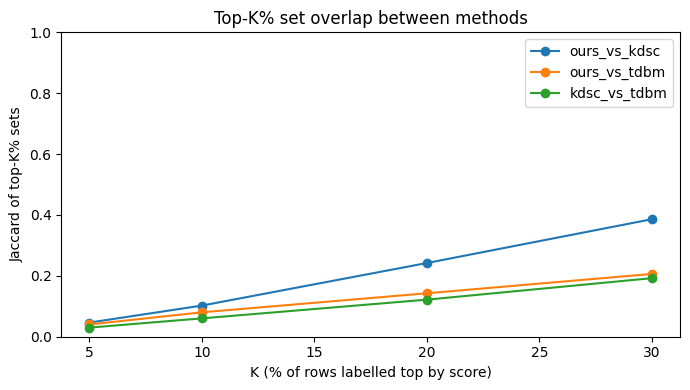

In [11]:
# Jaccard vs K, one line per pair
fig, ax = plt.subplots(figsize=(7, 4))
for pair in overlap_df['pair'].unique():
    sub = overlap_df[overlap_df['pair'] == pair]
    ax.plot(sub['k_pct'], sub['jaccard'], marker='o', label=pair)
ax.set_xlabel('K (% of rows labelled top by score)')
ax.set_ylabel('Jaccard of top-K% sets')
ax.set_title('Top-K% set overlap between methods')
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'jaccard_vs_k.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Save the joined table with all three scores

In [12]:
joined.to_parquet(OUT_DIR / f'{DATASET}_val_with_scores.parquet', index=False)

report = {
    'dataset': DATASET,
    'n_joined': int(len(joined)),
    'aggressive_share': {
        'ours': float((joined['style_label']      == 'aggressive').mean()),
        'kdsc': float((joined['style_label_kdsc'] == 'aggressive').mean()),
        'tdbm': float((joined['style_label_tdbm'] == 'aggressive').mean()),
    },
    'rank_correlations':       rho_df.to_dict(orient='records'),
    'topk_overlap':            overlap_df.to_dict(orient='records'),
    'topk_focus_k_pct':        K_FOCUS,
    'topk_focus_feature_stats': wide.reset_index().to_dict(orient='records'),
    'cohens_d_topk':           d_df.to_dict(),
    'ks_stat_topk':            ks_df.to_dict(),
}
with open(OUT_DIR / 'comparison_report.json', 'w') as f:
    json.dump(report, f, indent=2, default=float)
print('Saved:')
for p in sorted(OUT_DIR.rglob('*')):
    if p.is_file():
        print(' ', p.relative_to(REPO_ROOT))

TypeError: keys must be str, int, float, bool or None, not tuple